In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [8]:
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [10]:
# Drop columns with too many missing values
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu'])

# Fill numeric missing values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values with 'None'
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('None')

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [11]:
# Encode categorical columns as numbers
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Define features and target
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1168, 74)
Test set size: (292, 74)


In [12]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=100)

[0]	validation_0-rmse:84084.18441
[100]	validation_0-rmse:25377.84874
[200]	validation_0-rmse:24711.18103
[300]	validation_0-rmse:24656.84208
[400]	validation_0-rmse:24637.33088
[500]	validation_0-rmse:24639.43090
[600]	validation_0-rmse:24651.09537
[700]	validation_0-rmse:24649.33561
[800]	validation_0-rmse:24647.57799
[900]	validation_0-rmse:24636.29417
[999]	validation_0-rmse:24634.75473


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"Root Mean Squared Error: ${rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: $16,094
Root Mean Squared Error: $24,635
R² Score: 0.9209


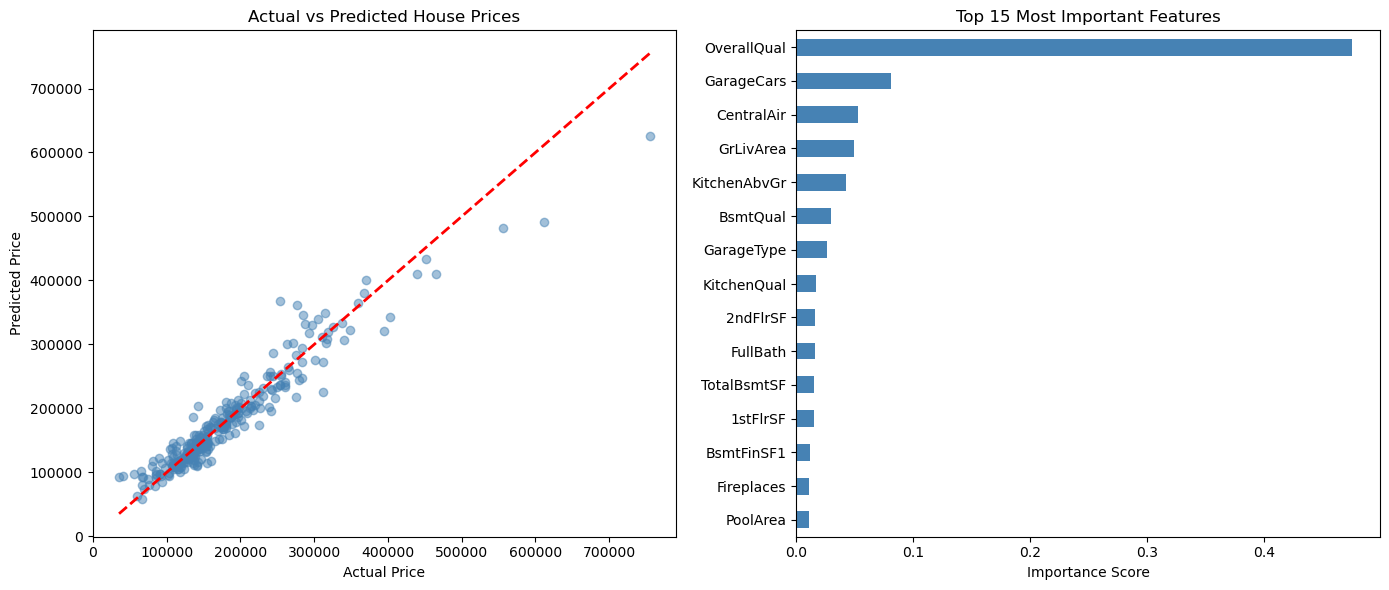

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs predicted prices
ax1.scatter(y_test, predictions, alpha=0.5, color='steelblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')
ax1.set_title('Actual vs Predicted House Prices')

# Top 15 most important features
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(15).sort_values().plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Top 15 Most Important Features')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()